# Compare embeddings: with-type vs xyz-only

Loads two trained checkpoints (xyz-only and xyz + 4-dim node-type one-hot), computes latents for the same set of neurons, and compares the resulting embedding spaces.

Sections:
1. Load both models and run inference
2. KMeans clustering on each + confusion matrix
3. Cluster-agreement metrics (ARI, NMI)
4. Side-by-side t-SNE colored by the *other* model's clusters
5. CKA / linear-probe comparisons (representation similarity)
6. Per-cluster type composition (only the with-type model can lean on this)

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0
%load_ext autoreload
%autoreload 2

import os, json, copy
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, adjusted_rand_score,
                             normalized_mutual_info_score, silhouette_score)
from scipy.optimize import linear_sum_assignment

from ssl_neuron.datasets import GraphDataset
from ssl_neuron.utils import (plot_neuron, neighbors_to_adjacency_torch,
                              compute_eig_lapl_torch_batch)
from ssl_neuron.graphdino import create_model

fig_save_path = './figures/'
os.makedirs(fig_save_path, exist_ok=True)

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0


## 1. Load both configs, datasets, and checkpoints
Two `GraphDataset` instances are built because the feature width differs (3 vs 7). Sample order is the same because both read `all_ids.npy`.

In [2]:
CKPT_NOTYPE  = '../ckpts/ckpt_15000.pt'
CKPT_WITHTYPE = '../ckpts_with_type/ckpt_15000.pt'

config_notype = json.load(open('../configs/config_inf.json'))
config_notype['data']['path'] = '../data/'
config_notype['data']['use_type'] = False
config_notype['data']['feat_dim'] = 3

config_withtype = json.load(open('../configs/config_with_type.json'))
config_withtype['data']['path'] = '../data/'
# Match the inference-time settings (n_nodes etc.) from config_inf.
config_withtype['data']['n_nodes']   = config_notype['data']['n_nodes']
config_withtype['data']['batch_size']= config_notype['data']['batch_size']

In [3]:
dset_notype   = GraphDataset(config_notype,   mode='all')
dset_withtype = GraphDataset(config_withtype, mode='all')
all_ids = np.load('../data/all_ids.npy')
assert dset_notype.num_samples == dset_withtype.num_samples
n = dset_notype.num_samples
print(f'{n} neurons.')

100%|██████████| 466/466 [00:07<00:00, 61.54it/s]

461 neurons.


In [4]:
def load_model(config, ckpt_path):
    model = create_model(config)
    sd = torch.load(ckpt_path, map_location='cpu')['model']
    model.load_state_dict(sd)
    model.eval().cuda()
    return model

model_notype   = load_model(config_notype,   CKPT_NOTYPE)
model_withtype = load_model(config_withtype, CKPT_WITHTYPE)

In [5]:
@torch.no_grad()
def encode_dataset(model, dset, pos_dim):
    out = []
    for i in tqdm(range(dset.num_samples)):
        feat, neigh = dset.__getsingleitem__(i)
        adj  = neighbors_to_adjacency_torch(neigh, list(neigh.keys())).float().cuda()[None]
        lapl = compute_eig_lapl_torch_batch(adj, pos_enc_dim=pos_dim).float().cuda()
        f    = torch.from_numpy(feat).float().cuda()[None]
        z    = model.student_encoder.forward(f, adj, lapl)
        z    = z[0].cpu().numpy()           # drop batch dim
        if z.ndim == 2:                      # (N_nodes, dim) -> pool to graph-level
            z = z.mean(axis=0)
        out.append(z)
    return np.stack(out)                    # (n_neurons, dim)

lat_notype   = encode_dataset(model_notype,   dset_notype,   config_notype['model']['pos_dim'])
lat_withtype = encode_dataset(model_withtype, dset_withtype, config_withtype['model']['pos_dim'])
lat_notype.shape, lat_withtype.shape


100%|██████████| 461/461 [00:21<00:00, 21.30it/s]


((461, 32), (461, 32))

## 2. KMeans on each embedding + confusion matrix
We Hungarian-align the cluster IDs so the diagonal of the confusion matrix is the best-case agreement. The remaining off-diagonal mass is the disagreement between the two embeddings' partitions.

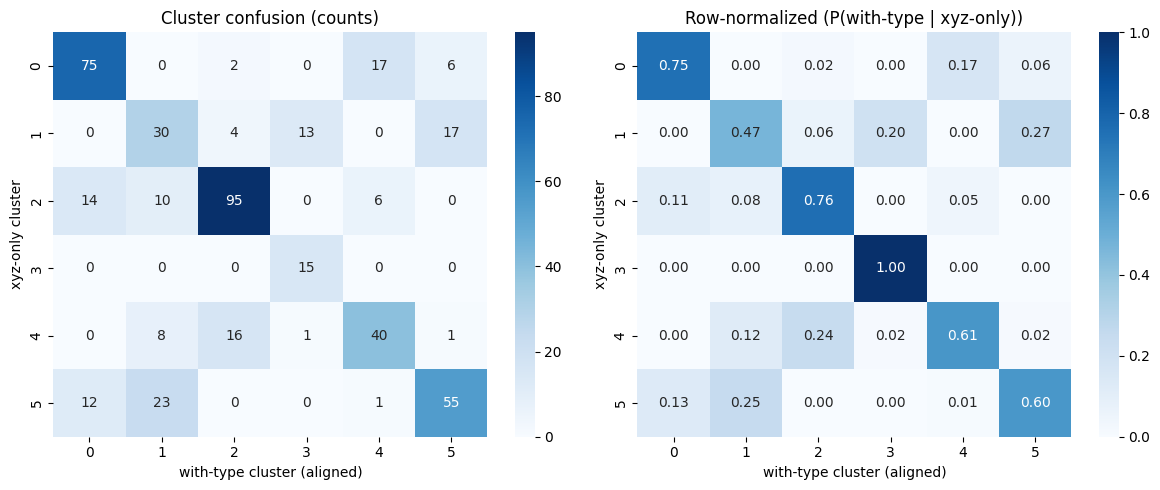

Diagonal agreement after Hungarian alignment: 0.672


In [6]:
N_CLUSTERS = 6
SEED = 0

km_notype   = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10).fit(lat_notype)
km_withtype = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10).fit(lat_withtype)
lab_notype, lab_withtype = km_notype.labels_, km_withtype.labels_

def hungarian_align(labels_src, labels_ref, k):
    """Return a permutation `p` such that p[labels_src] best matches labels_ref."""
    M = confusion_matrix(labels_ref, labels_src, labels=list(range(k)))
    row, col = linear_sum_assignment(-M)  # maximize matches
    perm = np.zeros(k, dtype=int)
    perm[col] = row
    return perm

perm = hungarian_align(lab_withtype, lab_notype, N_CLUSTERS)
lab_withtype_aligned = perm[lab_withtype]

cm = confusion_matrix(lab_notype, lab_withtype_aligned, labels=list(range(N_CLUSTERS)))
row_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Cluster confusion (counts)')
axes[0].set_xlabel('with-type cluster (aligned)')
axes[0].set_ylabel('xyz-only cluster')
sns.heatmap(row_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Row-normalized (P(with-type | xyz-only))')
axes[1].set_xlabel('with-type cluster (aligned)')
axes[1].set_ylabel('xyz-only cluster')
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'compare_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

diag_frac = np.trace(cm) / cm.sum()
print(f'Diagonal agreement after Hungarian alignment: {diag_frac:.3f}')

## 3. Partition-agreement metrics
These are permutation-invariant, so we don't need the alignment step.
- **ARI** is chance-corrected: 0 = random, 1 = identical partitions.
- **NMI** is information-theoretic: 0 = independent, 1 = identical.
- **Silhouette** scores how compact each clustering is in its own embedding space — for context, not for direct comparison across spaces.

In [7]:
ari = adjusted_rand_score(lab_notype, lab_withtype)
nmi = normalized_mutual_info_score(lab_notype, lab_withtype)
sil_notype   = silhouette_score(lat_notype,   lab_notype)
sil_withtype = silhouette_score(lat_withtype, lab_withtype)
print(f'ARI (xyz-only vs with-type) : {ari:.3f}')
print(f'NMI                          : {nmi:.3f}')
print(f'Silhouette (xyz-only)        : {sil_notype:.3f}')
print(f'Silhouette (with-type)       : {sil_withtype:.3f}')

ARI (xyz-only vs with-type) : 0.430
NMI                          : 0.490
Silhouette (xyz-only)        : 0.246
Silhouette (with-type)       : 0.254


## 4. Side-by-side t-SNE
Each panel is its own t-SNE; coloring by the *other* model's clusters reveals whether structure is preserved across embeddings.

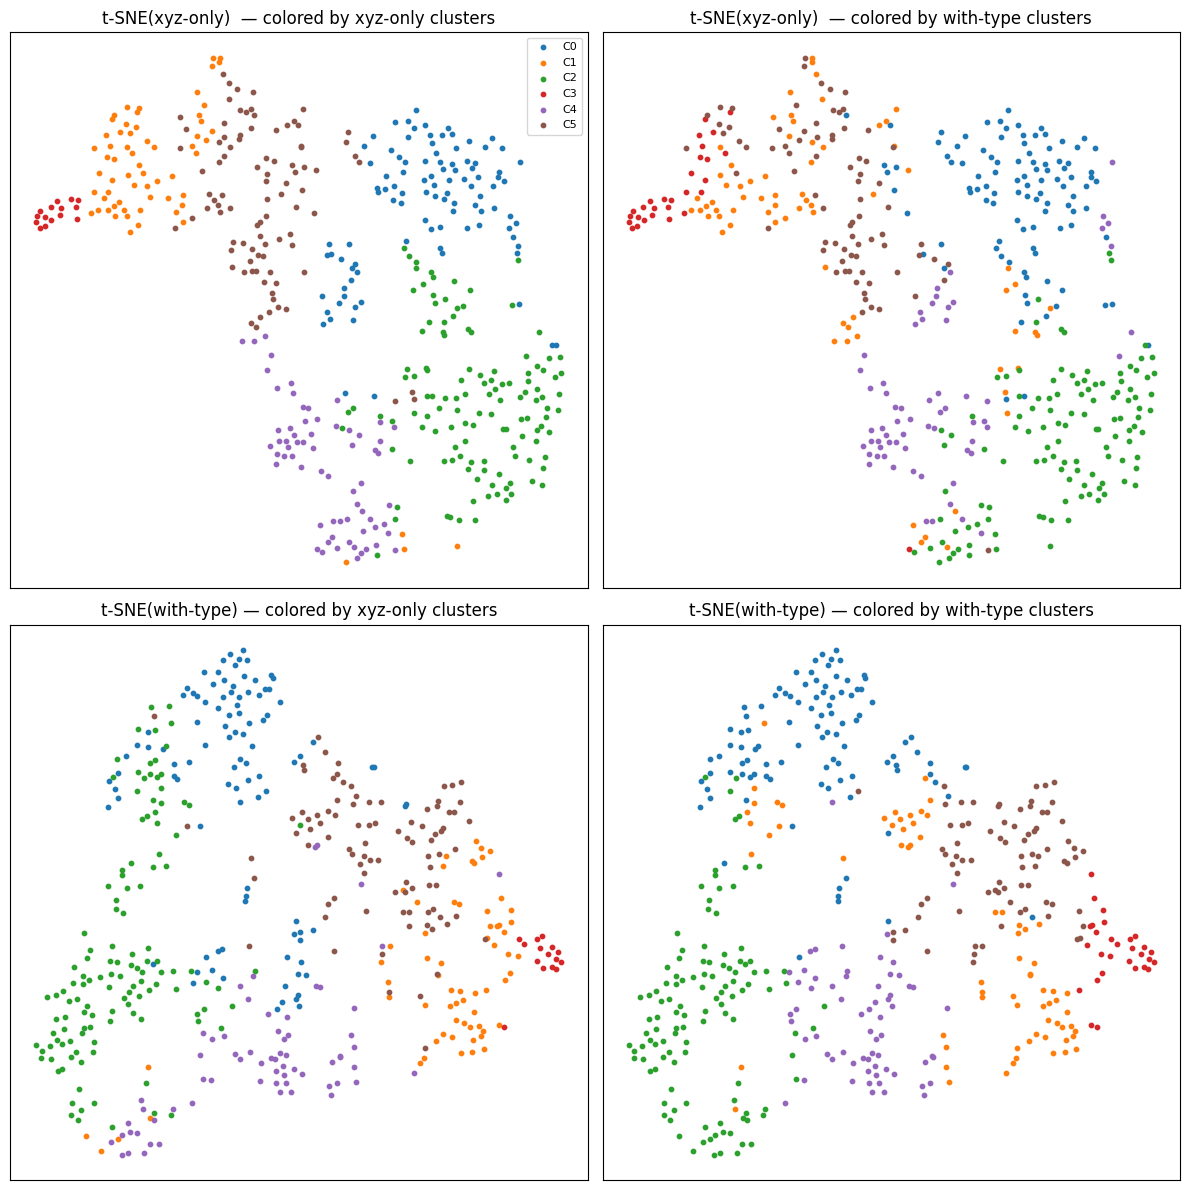

In [8]:
z_notype   = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(lat_notype)
z_withtype = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(lat_withtype)
palette = sns.color_palette('tab10', n_colors=N_CLUSTERS)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, z, lab, title in [
    (axes[0, 0], z_notype,   lab_notype,            't-SNE(xyz-only)  — colored by xyz-only clusters'),
    (axes[0, 1], z_notype,   lab_withtype_aligned,  't-SNE(xyz-only)  — colored by with-type clusters'),
    (axes[1, 0], z_withtype, lab_notype,            't-SNE(with-type) — colored by xyz-only clusters'),
    (axes[1, 1], z_withtype, lab_withtype_aligned,  't-SNE(with-type) — colored by with-type clusters'),
]:
    for c in range(N_CLUSTERS):
        m = lab == c
        ax.scatter(z[m, 0], z[m, 1], s=10, color=palette[c], label=f'C{c}')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'compare_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Representation similarity (CKA + linear probe)
Cluster-level agreement can be coarse — two embeddings can carve the same partition but still encode very different per-neuron structure. CKA (linear) measures how similar the two latent spaces are at the *vector* level (chance-invariant to rotation/scale).

We also fit a small linear probe from one space to the other; high R² means one space is essentially a linear map of the other (i.e. type info added little).

In [9]:
def linear_cka(X, Y):
    X = X - X.mean(0); Y = Y - Y.mean(0)
    num = np.linalg.norm(X.T @ Y, 'fro') ** 2
    den = np.linalg.norm(X.T @ X, 'fro') * np.linalg.norm(Y.T @ Y, 'fro')
    return num / den

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

def cv_r2(X, Y, alpha=1.0, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=0)
    r2s = []
    for tr, te in kf.split(X):
        m = Ridge(alpha=alpha).fit(X[tr], Y[tr])
        r2s.append(m.score(X[te], Y[te]))
    return np.mean(r2s)

cka = linear_cka(lat_notype, lat_withtype)
r2_n2w = cv_r2(lat_notype,   lat_withtype)
r2_w2n = cv_r2(lat_withtype, lat_notype)
print(f'Linear CKA(xyz-only, with-type)         : {cka:.3f}')
print(f'Ridge R^2  xyz-only -> with-type (5-fold): {r2_n2w:.3f}')
print(f'Ridge R^2  with-type -> xyz-only (5-fold): {r2_w2n:.3f}')

Linear CKA(xyz-only, with-type)         : 0.849
Ridge R^2  xyz-only -> with-type (5-fold): 0.896
Ridge R^2  with-type -> xyz-only (5-fold): 0.897


## 6. Type composition per cluster
For the with-type model, what fraction of nodes per cluster are axon / dendrite / synapse / soma? If the encoder is using the type one-hot, clusters should differ in their average type histogram. The xyz-only model gives a baseline (it never saw types, so any cluster-type structure is purely geometric).

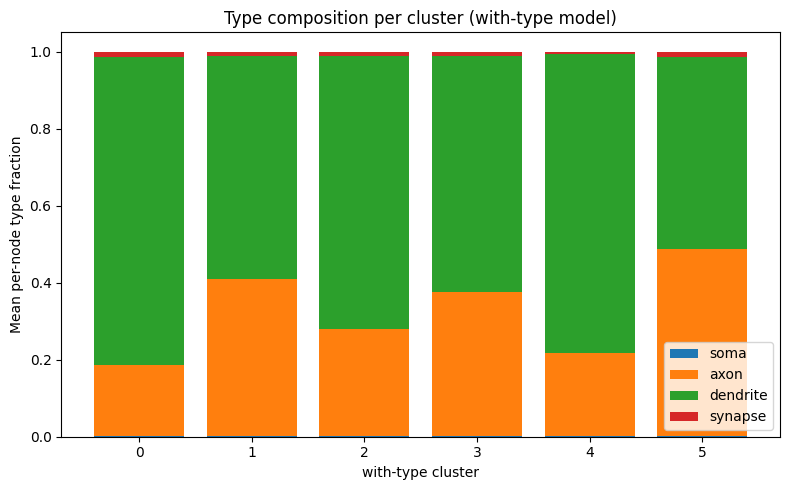

In [10]:
TYPE_NAMES = ['soma', 'axon', 'dendrite', 'synapse']

def per_cluster_type_hist(dset, labels, k):
    """Mean per-node type distribution per cluster (uses the with-type dataset's 4-dim one-hot)."""
    sums = np.zeros((k, 4))
    counts = np.zeros(k)
    for i in range(dset.num_samples):
        feat = dset.cells[i]['features']  # (n_nodes, 7) when use_type=True
        if feat.shape[1] < 7:
            return None  # xyz-only dataset: type info not present
        sums[labels[i]]   += feat[:, 3:7].mean(axis=0)
        counts[labels[i]] += 1
    return sums / counts[:, None]

hist = per_cluster_type_hist(dset_withtype, lab_withtype, N_CLUSTERS)
if hist is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    bottom = np.zeros(N_CLUSTERS)
    for t in range(4):
        ax.bar(np.arange(N_CLUSTERS), hist[:, t], bottom=bottom, label=TYPE_NAMES[t])
        bottom += hist[:, t]
    ax.set_xlabel('with-type cluster')
    ax.set_ylabel('Mean per-node type fraction')
    ax.set_title('Type composition per cluster (with-type model)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_save_path, 'compare_type_composition.png'), dpi=150, bbox_inches='tight')
    plt.show()

## What to look at
- **Confusion matrix + ARI/NMI**: how much do the partitions agree? Low ARI with high CKA means the types reorganized cluster boundaries but the underlying geometry is preserved.
- **CKA / linear probe**: if R² is high in both directions, the type info adds at most a linear shift — probably not worth the extra parameters.
- **Silhouette**: which embedding gives more separable clusters at K=6? Repeat over a sweep of K (2..15) for a fairer picture.
- **Type composition**: if with-type clusters split cleanly by axon/dendrite ratio while xyz-only clusters don't, the model is leveraging type. If both look similar, geometry alone already encodes type.
- **Held-out probing**: train a linear classifier on the latents to predict any external label you have (e.g. true neuron class, brain region) and compare accuracy.
- **kNN consistency**: for each neuron, look at the overlap of its top-10 neighbors across the two embeddings — a per-cell version of ARI.